In [78]:
# just importing all the main libraries I need to use and turning off any annoying warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [79]:
# loading the csv file  and showing the first few rows to check it worked
file_path = "2023-metropolitan-street-all.csv"

df = pd.read_csv(file_path)

df.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,8536e93fb3ce916daa4251bd53c1a4416ba4159a938340...,2023-01,Metropolitan Police Service,Metropolitan Police Service,-0.681541,50.792113,On or near Fletcher Way,E01031444,Arun 016B,Violence and sexual offences,Status update unavailable,NaN
1,483d52d514591a895c829dece6091c31f797b7dcfd0735...,2023-01,Metropolitan Police Service,Metropolitan Police Service,-0.684107,50.780541,On or near Victoria Road South,E01031437,Arun 017E,Other theft,Investigation complete; no suspect identified,NaN
2,63343c1f1236bad8ce08d130f37760172dc33b20af2b56...,2023-01,Metropolitan Police Service,Metropolitan Police Service,-0.928552,51.923331,On or near St Marys Close,E01017714,Aylesbury Vale 004D,Violence and sexual offences,Status update unavailable,NaN
3,a3d980f554d3ece9e8dcda8518ae87bfa9c75d62396105...,2023-01,Metropolitan Police Service,Metropolitan Police Service,-0.772051,51.827897,On or near Restharrow Road,E01017641,Aylesbury Vale 007A,Violence and sexual offences,Investigation complete; no suspect identified,NaN
4,bfb1d1da32341b7129e789130001d96f7e603088593dc5...,2023-01,Metropolitan Police Service,Metropolitan Police Service,-0.804965,51.811332,On or near Walton Grove,E01017637,Aylesbury Vale 017C,Violence and sexual offences,Status update unavailable,NaN


In [80]:
# Quick check on the dataset size, column and type info to understand it better
print(df.shape)
print(df.columns)
print(df.dtypes)
df.info()

(1135031, 12)
Index(['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude',
       'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type',
       'Last outcome category', 'Context'],
      dtype='str')
Crime ID                     str
Month                        str
Reported by                  str
Falls within                 str
Longitude                float64
Latitude                 float64
Location                     str
LSOA code                    str
LSOA name                    str
Crime type                   str
Last outcome category        str
Context                  float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 1135031 entries, 0 to 1135030
Data columns (total 12 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Crime ID               912185 non-null   str    
 1   Month                  1135031 non-null  str    
 2   Reported by            1135031 non-null  str   

In [81]:
# Checking how many missing values there are in each column
df.isnull().sum()

Crime ID                  222846
Month                          0
Reported by                    0
Falls within                   0
Longitude                  23588
Latitude                   23588
Location                       0
LSOA code                  23588
LSOA name                  23588
Crime type                     0
Last outcome category     222846
Context                  1135031
dtype: int64

In [82]:
#checking for duplicates
df.duplicated().sum()

np.int64(105752)

In [83]:
# Trimming extra spaces from all text columns. This helps with cleaning.
df[df.select_dtypes('object').columns] = df.select_dtypes('object').apply(lambda x: x.str.strip())

In [84]:
# dropping unnecessary columns
drop_cols = ['Crime ID', 'Context', 'Reported by', 'Falls within', 'Location']

df.drop(columns=drop_cols, inplace=True, errors='ignore')

df.head()

,Month,Longitude,Latitude,LSOA code,LSOA name,Crime type,Last outcome category
0,2023-01,-0.681541,50.792113,E01031444,Arun 016B,Violence and sexual offences,Status update unavailable
1,2023-01,-0.684107,50.780541,E01031437,Arun 017E,Other theft,Investigation complete; no suspect identified
2,2023-01,-0.928552,51.923331,E01017714,Aylesbury Vale 004D,Violence and sexual offences,Status update unavailable
3,2023-01,-0.772051,51.827897,E01017641,Aylesbury Vale 007A,Violence and sexual offences,Investigation complete; no suspect identified
4,2023-01,-0.804965,51.811332,E01017637,Aylesbury Vale 017C,Violence and sexual offences,Status update unavailable


In [85]:
# removing duplicate and checking the new size of the dataset
df.drop_duplicates(inplace=True)

df.shape

(783463, 7)

In [86]:
# filling missing values (text with "Unknown" and numbers with backfill)
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].bfill()

df.isnull().sum()

Month                     0
Longitude                44
Latitude                 44
LSOA code                 0
LSOA name                 0
Crime type                0
Last outcome category     0
dtype: int64

In [87]:
# Converting the month column to datetime and extracting year and month number for easier analysis later on
df['Month'] = pd.to_datetime(df['Month'])

df['year'] = df['Month'].dt.year
df['month_num'] = df['Month'].dt.month

df.head()

,Month,Longitude,Latitude,LSOA code,LSOA name,Crime type,Last outcome category,year,month_num
0,2023-01-01,-0.681541,50.792113,E01031444,Arun 016B,Violence and sexual offences,Status update unavailable,2023,1
1,2023-01-01,-0.684107,50.780541,E01031437,Arun 017E,Other theft,Investigation complete; no suspect identified,2023,1
2,2023-01-01,-0.928552,51.923331,E01017714,Aylesbury Vale 004D,Violence and sexual offences,Status update unavailable,2023,1
3,2023-01-01,-0.772051,51.827897,E01017641,Aylesbury Vale 007A,Violence and sexual offences,Investigation complete; no suspect identified,2023,1
4,2023-01-01,-0.804965,51.811332,E01017637,Aylesbury Vale 017C,Violence and sexual offences,Status update unavailable,2023,1


In [88]:
# Grouping the data by area and date to count how many crimes happened in each group
crime_counts = df.groupby(['LSOA code', 'LSOA name', 'year', 'month_num']).size().reset_index(name='crime_count')

crime_counts.head()

,LSOA code,LSOA name,year,month_num,crime_count
0,E01000001,City of London 001A,2023,1,2
1,E01000001,City of London 001A,2023,2,2
2,E01000001,City of London 001A,2023,3,3
3,E01000001,City of London 001A,2023,5,2
4,E01000001,City of London 001A,2023,6,2


In [89]:
# Counting how many different crime types occur in each area and time period
unique_types = (
    df.groupby(['LSOA code', 'LSOA name', 'year', 'month_num'])['Crime type']
      .nunique()
      .reset_index(name='n_unique_crime_types')
)

unique_types.head()

,LSOA code,LSOA name,year,month_num,n_unique_crime_types
0,E01000001,City of London 001A,2023,1,2
1,E01000001,City of London 001A,2023,2,2
2,E01000001,City of London 001A,2023,3,3
3,E01000001,City of London 001A,2023,5,2
4,E01000001,City of London 001A,2023,6,2


In [90]:
# Finding the most common crime type in each area and time period
top_crime_type = (
    df.groupby(['LSOA code', 'LSOA name', 'year', 'month_num', 'Crime type'])
      .size()
      .reset_index(name='type_count')
      .sort_values(['LSOA code', 'LSOA name', 'year', 'month_num', 'type_count'],
                   ascending=[True, True, True, True, False])
      .drop_duplicates(subset=['LSOA code', 'LSOA name', 'year', 'month_num'])
      .rename(columns={'Crime type': 'top_crime_type'})
)

top_crime_type = top_crime_type[['LSOA code', 'LSOA name', 'year', 'month_num', 'top_crime_type']]

top_crime_type.head()

,LSOA code,LSOA name,year,month_num,top_crime_type
0,E01000001,City of London 001A,2023,1,Burglary
2,E01000001,City of London 001A,2023,2,Criminal damage and arson
4,E01000001,City of London 001A,2023,3,Criminal damage and arson
7,E01000001,City of London 001A,2023,5,Anti-social behaviour
9,E01000001,City of London 001A,2023,6,Criminal damage and arson


In [91]:
# Finding the most common outcome category for each area and time period
top_outcome = (
    df.groupby(['LSOA code', 'LSOA name', 'year', 'month_num', 'Last outcome category'])
      .size()
      .reset_index(name='outcome_count')
      .sort_values(['LSOA code', 'LSOA name', 'year', 'month_num', 'outcome_count'],
                   ascending=[True, True, True, True, False])
      .drop_duplicates(subset=['LSOA code', 'LSOA name', 'year', 'month_num'])
      .rename(columns={'Last outcome category': 'top_outcome'})
)

top_outcome = top_outcome[['LSOA code', 'LSOA name', 'year', 'month_num', 'top_outcome']]

top_outcome.head()

,LSOA code,LSOA name,year,month_num,top_outcome
0,E01000001,City of London 001A,2023,1,Investigation complete; no suspect identified
2,E01000001,City of London 001A,2023,2,Investigation complete; no suspect identified
4,E01000001,City of London 001A,2023,3,Investigation complete; no suspect identified
6,E01000001,City of London 001A,2023,5,Investigation complete; no suspect identified
8,E01000001,City of London 001A,2023,6,Status update unavailable


In [92]:
# Merging all the created features together into one final dataset for modelling
model_df = crime_counts.merge(unique_types, on=['LSOA code', 'LSOA name', 'year', 'month_num'], how='left')
model_df = model_df.merge(top_crime_type, on=['LSOA code', 'LSOA name', 'year', 'month_num'], how='left')
model_df = model_df.merge(top_outcome, on=['LSOA code', 'LSOA name', 'year', 'month_num'], how='left')

model_df.head()

,LSOA code,LSOA name,year,month_num,crime_count,n_unique_crime_types,top_crime_type,top_outcome
0,E01000001,City of London 001A,2023,1,2,2,Burglary,Investigation complete; no suspect identified
1,E01000001,City of London 001A,2023,2,2,2,Criminal damage and arson,Investigation complete; no suspect identified
2,E01000001,City of London 001A,2023,3,3,3,Criminal damage and arson,Investigation complete; no suspect identified
3,E01000001,City of London 001A,2023,5,2,2,Anti-social behaviour,Investigation complete; no suspect identified
4,E01000001,City of London 001A,2023,6,2,2,Criminal damage and arson,Status update unavailable


In [93]:
# Sorting the data and adding a feature for last month's crime count in each area
model_df = model_df.sort_values(['LSOA code', 'year', 'month_num'])

model_df['prev_month_crime_count'] = model_df.groupby('LSOA code')['crime_count'].shift(1)

model_df['prev_month_crime_count'] = model_df['prev_month_crime_count'].fillna(0)

model_df.head()

,LSOA code,LSOA name,year,month_num,crime_count,n_unique_crime_types,top_crime_type,top_outcome,prev_month_crime_count
0,E01000001,City of London 001A,2023,1,2,2,Burglary,Investigation complete; no suspect identified,0.0
1,E01000001,City of London 001A,2023,2,2,2,Criminal damage and arson,Investigation complete; no suspect identified,2.0
2,E01000001,City of London 001A,2023,3,3,3,Criminal damage and arson,Investigation complete; no suspect identified,2.0
3,E01000001,City of London 001A,2023,5,2,2,Anti-social behaviour,Investigation complete; no suspect identified,3.0
4,E01000001,City of London 001A,2023,6,2,2,Criminal damage and arson,Status update unavailable,2.0


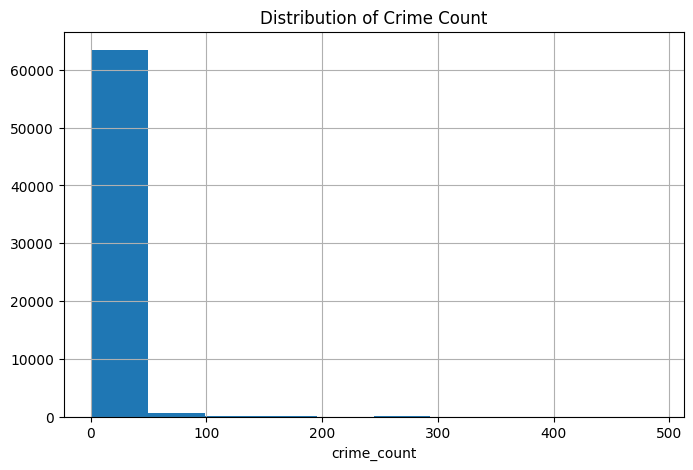

In [94]:
# Plotting a simple histogram to see how crime counts are distributed
plt.figure(figsize=(8,5))
plt.hist(model_df['crime_count'])
plt.xlabel('crime_count')
plt.title('Distribution of Crime Count')
plt.grid()
plt.show()

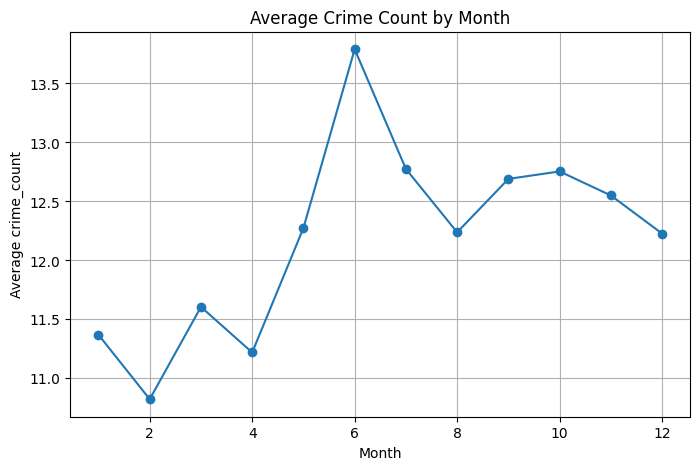

In [95]:
#simple line graph plot
monthly_counts = model_df.groupby('month_num')['crime_count'].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Average crime_count')
plt.title('Average Crime Count by Month')
plt.grid()
plt.show()

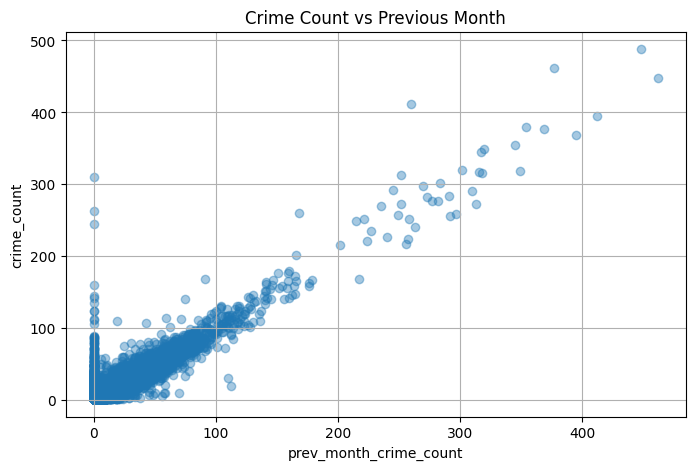

In [96]:
#simple scatter graph plot
plt.figure(figsize=(8,5))
plt.scatter(model_df['prev_month_crime_count'], model_df['crime_count'], alpha=0.4)
plt.xlabel('prev_month_crime_count')
plt.ylabel('crime_count')
plt.title('Crime Count vs Previous Month')
plt.grid()
plt.show()

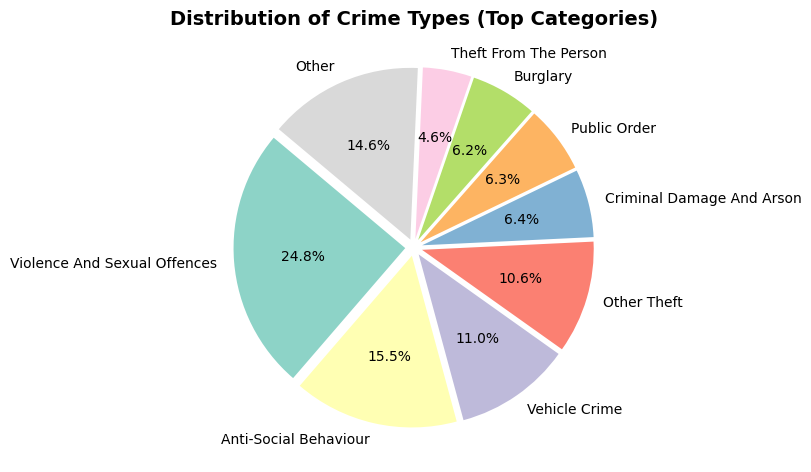

In [ ]:
# Pie chart of the most common crime types
import matplotlib.pyplot as plt

crime_counts = df['Crime type'].value_counts()

TOP_N = 8
top_crimes = crime_counts.head(TOP_N).copy()

other_count = crime_counts.iloc[TOP_N:].sum()
if other_count > 0:
    top_crimes.loc['Other'] = other_count

top_crimes.index = top_crimes.index.str.replace('_', ' ').str.title()

explode = [0.05] * len(top_crimes)

plt.figure(figsize=(8, 8))

plt.pie(
    top_crimes.values,
    labels=top_crimes.index,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    colors=plt.cm.Set3.colors
)

plt.title("Distribution of Crime Types (Top Categories)", fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

In [98]:
model_df = pd.get_dummies(model_df, columns=['top_crime_type', 'top_outcome'], drop_first=True)

model_df.head()

,LSOA code,LSOA name,year,month_num,crime_count,n_unique_crime_types,prev_month_crime_count,top_crime_type_Bicycle theft,top_crime_type_Burglary,top_crime_type_Criminal damage and arson,...,top_outcome_Further action is not in the public interest,top_outcome_Further investigation is not in the public interest,top_outcome_Investigation complete; no suspect identified,top_outcome_Local resolution,top_outcome_Offender given a caution,top_outcome_Offender given a drugs possession warning,top_outcome_Offender given penalty notice,top_outcome_Status update unavailable,top_outcome_Unable to prosecute suspect,top_outcome_Unknown
0,E01000001,City of London 001A,2023,1,2,2,0.0,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,E01000001,City of London 001A,2023,2,2,2,2.0,False,False,True,...,False,False,True,False,False,False,False,False,False,False
2,E01000001,City of London 001A,2023,3,3,3,2.0,False,False,True,...,False,False,True,False,False,False,False,False,False,False
3,E01000001,City of London 001A,2023,5,2,2,3.0,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,E01000001,City of London 001A,2023,6,2,2,2.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False


In [99]:
# Splitting the data into features (X) and target (y) for modelling
X = model_df.drop(columns=['crime_count', 'LSOA code', 'LSOA name'])

y = model_df['crime_count']

X.head()

,year,month_num,n_unique_crime_types,prev_month_crime_count,top_crime_type_Bicycle theft,top_crime_type_Burglary,top_crime_type_Criminal damage and arson,top_crime_type_Drugs,top_crime_type_Other crime,top_crime_type_Other theft,...,top_outcome_Further action is not in the public interest,top_outcome_Further investigation is not in the public interest,top_outcome_Investigation complete; no suspect identified,top_outcome_Local resolution,top_outcome_Offender given a caution,top_outcome_Offender given a drugs possession warning,top_outcome_Offender given penalty notice,top_outcome_Status update unavailable,top_outcome_Unable to prosecute suspect,top_outcome_Unknown
0,2023,1,2,0.0,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,2023,2,2,2.0,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,2023,3,3,2.0,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,2023,5,2,3.0,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,2023,6,2,2.0,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [100]:
# Splitting the dataset into training and testing sets so we can evaluate the model properly
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=666)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 48231
Testing set size: 16077


In [101]:
# Training a linear regression model and using it to make predictions on the test set
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_train, y_train)

y_pred_lr = reg.predict(X_test)

In [102]:
# Checking how well the linear regression model performed using a few common metrics
from sklearn import metrics
import numpy as np

print("Linear Regression Performance")
print("R2:", metrics.r2_score(y_test, y_pred_lr))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_lr)))

Linear Regression Performance
R2: 0.8010703402415305
MSE: 40.44913740854037
RMSE: 6.359963632642908


In [103]:
# Training a random forest model and using it to make predictions on the test set
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=666)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [104]:
# Checking how well the random forest model performed using the same evaluation metrics
print("Random Forest Performance")
print("R2:", metrics.r2_score(y_test, y_pred_rf))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf)))

Random Forest Performance
R2: 0.9008354944735321
MSE: 20.163502591620393
RMSE: 4.490378891766305


In [ ]:
# Running cross-validation to check how well the random forest model performs across different splits
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

print("Cross-validation R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

Cross-validation R2 scores: [0.87730094 0.84301112 0.87249893 0.83786713 0.79088875]
Mean CV R2: 0.8443133743521543


In [106]:
# Looking at which features are most important in the random forest model
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

prev_month_crime_count                         0.629143
n_unique_crime_types                           0.336815
month_num                                      0.017972
top_crime_type_Violence and sexual offences    0.005332
top_crime_type_Other theft                     0.003311
top_crime_type_Theft from the person           0.002557
top_crime_type_Vehicle crime                   0.001197
top_crime_type_Burglary                        0.000663
top_crime_type_Drugs                           0.000586
top_crime_type_Shoplifting                     0.000525
dtype: float64

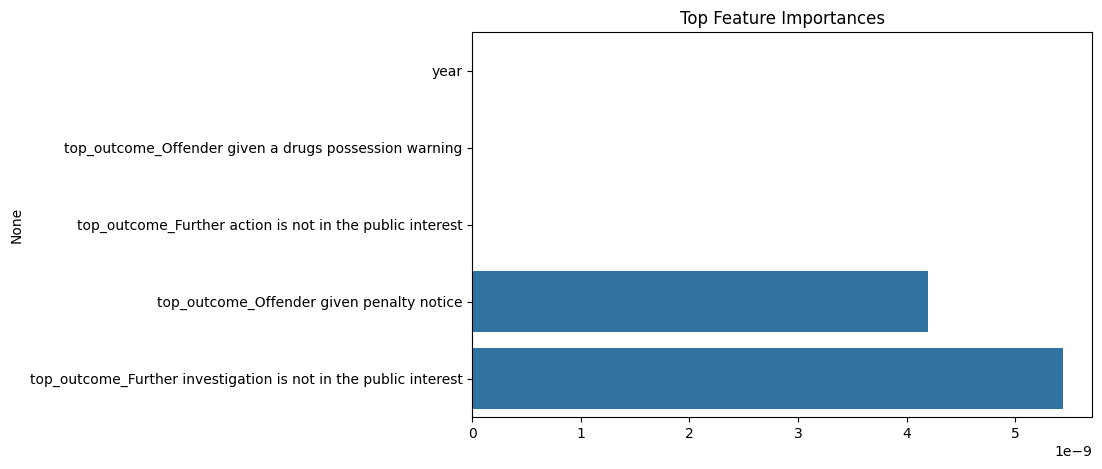

In [107]:
# Plotting a bar chart to visualise the most important features from the model
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure it's a Series
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

# Sort
top_features = feature_importance.sort_values(ascending=True).head(5)

plt.figure(figsize=(8,5))

sns.barplot(x=top_features.values, y=top_features.index)

plt.title("Top Feature Importances")

plt.show()

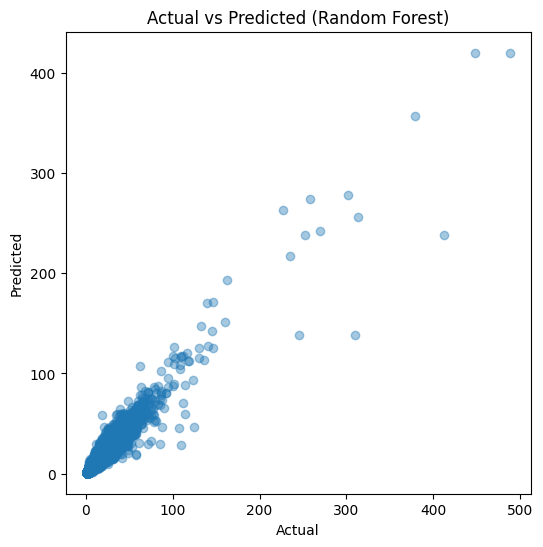

In [108]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.4)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

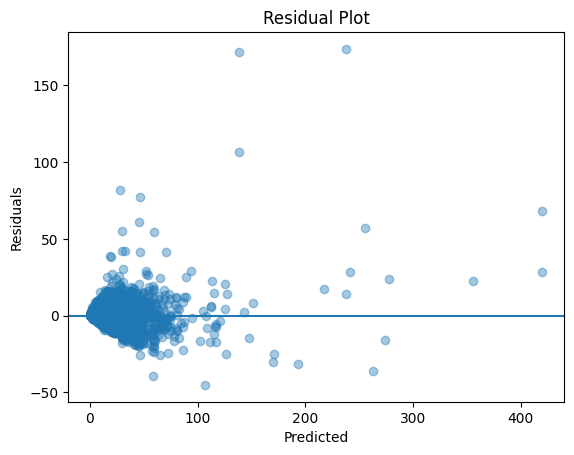

In [109]:
residuals = y_test - y_pred_rf

plt.scatter(y_pred_rf, residuals, alpha=0.4)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [110]:
# Selecting a few key features to use for clustering
cluster_df = model_df[['crime_count', 'prev_month_crime_count', 'n_unique_crime_types']]

cluster_df.head()

,crime_count,prev_month_crime_count,n_unique_crime_types
0,2,0.0,2
1,2,2.0,2
2,3,2.0,3
3,2,3.0,2
4,2,2.0,2


In [111]:
# Scaling the features so they’re all on the same range before clustering
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cluster_scaled = scaler.fit_transform(cluster_df)

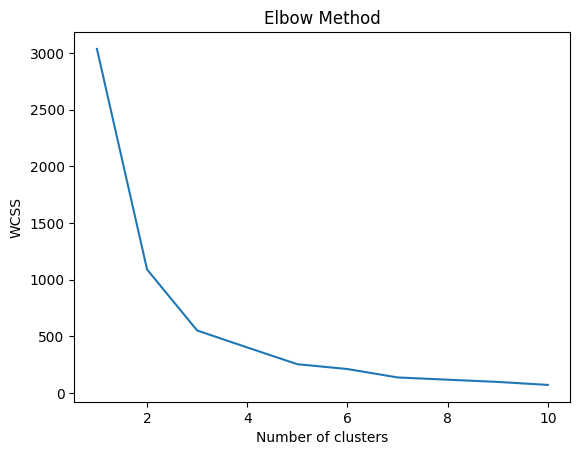

In [112]:
# Using the elbow method to help figure out the best number of clusters for k-means
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, max_iter=100, random_state=666)
    kmeans.fit(cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [113]:
# Running k-means with 3 clusters and adding the cluster labels back to the dataset
kmeans = KMeans(n_clusters=3, max_iter=100, random_state=666)

clusters = kmeans.fit_predict(cluster_scaled)

model_df['cluster'] = clusters

model_df.head()

,LSOA code,LSOA name,year,month_num,crime_count,n_unique_crime_types,prev_month_crime_count,top_crime_type_Bicycle theft,top_crime_type_Burglary,top_crime_type_Criminal damage and arson,...,top_outcome_Further investigation is not in the public interest,top_outcome_Investigation complete; no suspect identified,top_outcome_Local resolution,top_outcome_Offender given a caution,top_outcome_Offender given a drugs possession warning,top_outcome_Offender given penalty notice,top_outcome_Status update unavailable,top_outcome_Unable to prosecute suspect,top_outcome_Unknown,cluster
0,E01000001,City of London 001A,2023,1,2,2,0.0,False,True,False,...,False,True,False,False,False,False,False,False,False,0
1,E01000001,City of London 001A,2023,2,2,2,2.0,False,False,True,...,False,True,False,False,False,False,False,False,False,0
2,E01000001,City of London 001A,2023,3,3,3,2.0,False,False,True,...,False,True,False,False,False,False,False,False,False,0
3,E01000001,City of London 001A,2023,5,2,2,3.0,False,False,False,...,False,True,False,False,False,False,False,False,False,0
4,E01000001,City of London 001A,2023,6,2,2,2.0,False,False,True,...,False,False,False,False,False,False,True,False,False,0


In [114]:
# Calculating the silhouette score to see how well the clusters are separated
from sklearn.metrics import silhouette_score

score = silhouette_score(cluster_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.5518456641647965


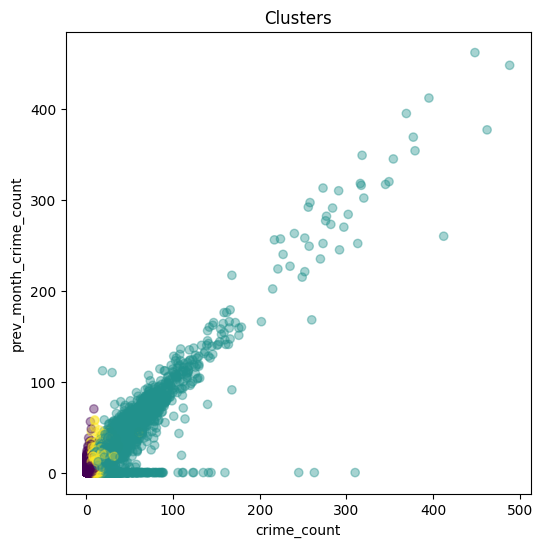

In [115]:
plt.figure(figsize=(6,6))
plt.scatter(cluster_df['crime_count'], cluster_df['prev_month_crime_count'], c=clusters, alpha=0.4)
plt.xlabel('crime_count')
plt.ylabel('prev_month_crime_count')
plt.title('Clusters')
plt.show()

In [116]:
# Summarising each cluster by looking at the average values of key features
cluster_summary = model_df.groupby('cluster')[['crime_count', 'prev_month_crime_count', 'n_unique_crime_types']].mean()

cluster_summary

,crime_count,prev_month_crime_count,n_unique_crime_types
cluster,,,
0,4.415443,5.023793,2.767955
1,24.938773,21.453339,9.378101
2,10.965835,9.878011,5.937985


In [117]:
# Picking out location codes and crime counts to prepare data for mapping
data_for_map = model_df[['LSOA code', 'crime_count']]

data_for_map.head()

,LSOA code,crime_count
0,E01000001,2
1,E01000001,2
2,E01000001,3
3,E01000001,2
4,E01000001,2


In [118]:
mapped = list(map(lambda row: (row['LSOA code'], row['crime_count']), data_for_map.to_dict('records')))

mapped[:10]

[('E01000001', 2),
 ('E01000001', 2),
 ('E01000001', 3),
 ('E01000001', 2),
 ('E01000001', 2),
 ('E01000001', 1),
 ('E01000001', 2),
 ('E01000001', 2),
 ('E01000001', 1),
 ('E01000002', 4)]

In [119]:
# Grouping crime counts by area code into a dictionary
grouped = {}

for key, value in mapped:
    grouped.setdefault(key, []).append(value)

list(grouped.items())[:5]

[('E01000001', [2, 2, 3, 2, 2, 1, 2, 2, 1]),
 ('E01000002', [4, 5, 6, 1, 7, 5, 5, 4, 4, 4, 3, 6]),
 ('E01000003', [1, 1, 3, 2, 3, 2, 6, 4, 2, 5, 5, 4]),
 ('E01000005', [8, 13, 7, 8, 19, 10, 13, 13, 21, 8, 15, 16]),
 ('E01000006', [7, 5, 6, 10, 4, 10, 9, 14, 4, 7, 5, 7])]

In [120]:
# Calculating the average crime count for each area code using reduce
from functools import reduce

reduced = {
    key: reduce(lambda a, b: a + b, values) / len(values)
    for key, values in grouped.items()
}

list(reduced.items())[:10]

[('E01000001', 1.8888888888888888),
 ('E01000002', 4.5),
 ('E01000003', 3.1666666666666665),
 ('E01000005', 12.583333333333334),
 ('E01000006', 7.333333333333333),
 ('E01000007', 34.75),
 ('E01000008', 22.166666666666668),
 ('E01000009', 26.0),
 ('E01000010', 71.6),
 ('E01000011', 6.0)]

In [121]:
# Training a Poisson regression model and checking how well it performs on the test data
from sklearn.linear_model import PoissonRegressor

poisson = PoissonRegressor(max_iter=1000)
poisson.fit(X_train, y_train)
y_pred_poisson = poisson.predict(X_test)

print("Poisson Regression Performance")
print("R2:", metrics.r2_score(y_test, y_pred_poisson))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_poisson)))

Poisson Regression Performance
R2: 0.6917637923134108
RMSE: 7.916745589118738


In [ ]:
# training a gradient boosting model and checking how well it performs
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import metrics
import numpy as np

gbr = GradientBoostingRegressor(random_state=666)
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

print("Gradient Boosting Performance")
print("R2:", metrics.r2_score(y_test, y_pred_gbr))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_gbr)))
print("MAE:", metrics.mean_absolute_error(y_test, y_pred_gbr))

Gradient Boosting Performance
R2: 0.9071925457248865
RMSE: 4.344064774408947
MAE: 2.275130803779772


In [ ]:
# Putting all model results together IN A TABLe like format so we can easily compare them
results = pd.DataFrame([
    {
        'Model': 'Linear Regression',
        'R2': metrics.r2_score(y_test, y_pred_lr),
        'RMSE': np.sqrt(metrics.mean_squared_error(y_test, y_pred_lr)),
        'MAE': metrics.mean_absolute_error(y_test, y_pred_lr)
    },
    {
        'Model': 'Random Forest',
        'R2': metrics.r2_score(y_test, y_pred_rf),
        'RMSE': np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf)),
        'MAE': metrics.mean_absolute_error(y_test, y_pred_rf)
    },
    {
        'Model': 'Poisson Regression',
        'R2': metrics.r2_score(y_test, y_pred_poisson),
        'RMSE': np.sqrt(metrics.mean_squared_error(y_test, y_pred_poisson)),
        'MAE': metrics.mean_absolute_error(y_test, y_pred_poisson)
    },
    {
        'Model': 'Gradient Boosting',
        'R2': metrics.r2_score(y_test, y_pred_gbr),
        'RMSE': np.sqrt(metrics.mean_squared_error(y_test, y_pred_gbr)),
        'MAE': metrics.mean_absolute_error(y_test, y_pred_gbr)
    }
])

results.sort_values("RMSE")

,Model,R2,RMSE,MAE
3,Gradient Boosting,0.907193,4.344065,2.275131
1,Random Forest,0.900835,4.490379,2.423816
0,Linear Regression,0.801070,6.359964,3.388778
2,Poisson Regression,0.691764,7.916746,2.904352


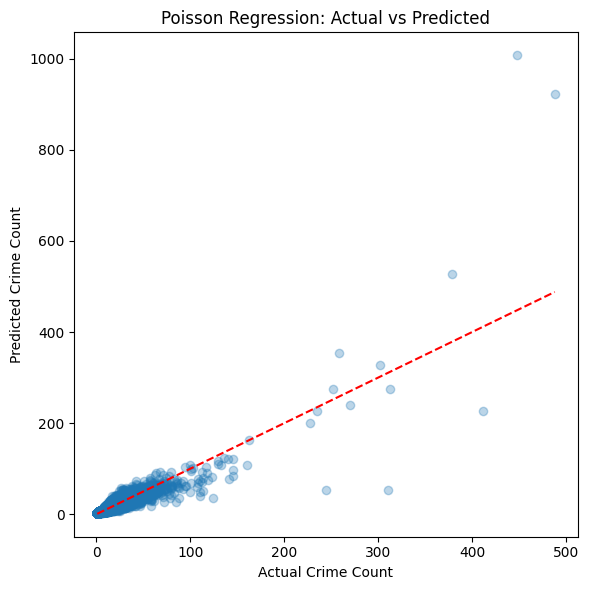

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_poisson, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Poisson Regression: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [125]:
# Looking at which features have the biggest impact in the Poisson regression model
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': poisson.coef_
}).sort_values(by='Coefficient', ascending=False)

coef_df.head(10)

,Feature,Coefficient
2,n_unique_crime_types,0.215330
16,top_crime_type_Violence and sexual offences,0.069865
22,top_outcome_Investigation complete; no suspect...,0.056414
9,top_crime_type_Other theft,0.026485
14,top_crime_type_Theft from the person,0.022291
15,top_crime_type_Vehicle crime,0.010654
29,top_outcome_Unknown,0.006952
3,prev_month_crime_count,0.006401
13,top_crime_type_Shoplifting,0.003068
20,top_outcome_Further action is not in the publi...,0.000000


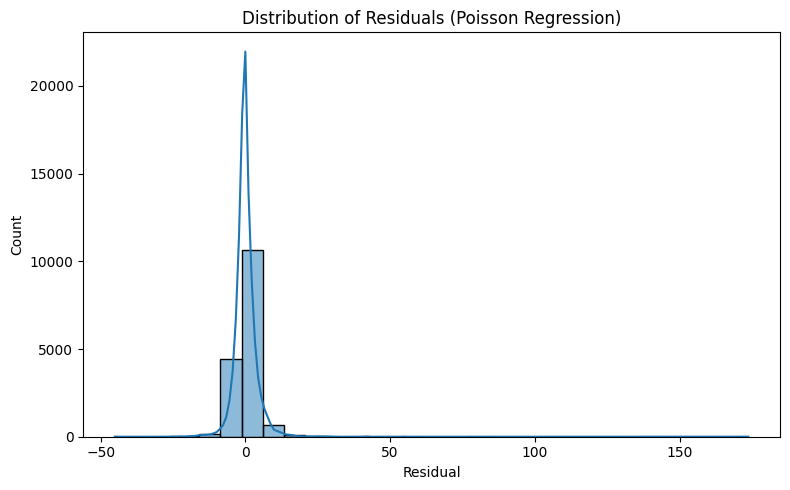

In [126]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True)

plt.title("Distribution of Residuals (Poisson Regression)")
plt.xlabel("Residual")

plt.tight_layout()
plt.show()

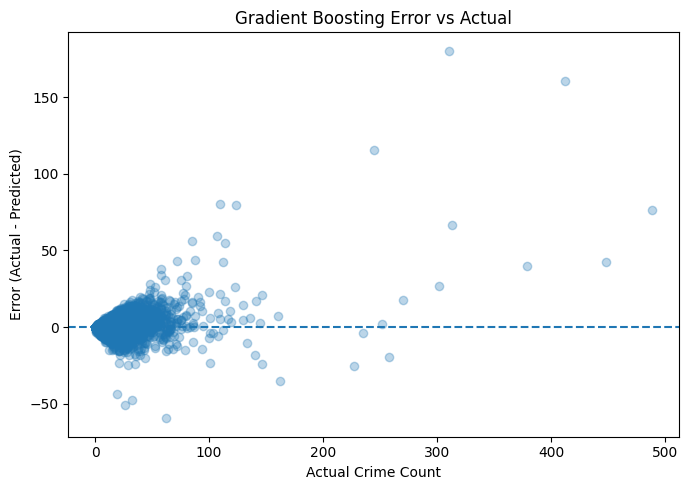

In [127]:
errors = y_test - y_pred_gbr

plt.figure(figsize=(7,5))
plt.scatter(y_test, errors, alpha=0.3)

plt.axhline(0, linestyle='--')

plt.xlabel("Actual Crime Count")
plt.ylabel("Error (Actual - Predicted)")
plt.title("Gradient Boosting Error vs Actual")

plt.tight_layout()
plt.show()

In [ ]:
# Tuning the gradient boosting model 
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=666),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_gbr = grid.best_estimator_
y_pred_best_gbr = best_gbr.predict(X_test)

print("Best Params:", grid.best_params_)
print("Tuned RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_best_gbr)))
print("Tuned R2:", metrics.r2_score(y_test, y_pred_best_gbr))

Best Params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
Tuned RMSE: 4.391806448029471
Tuned R2: 0.9051414112315327


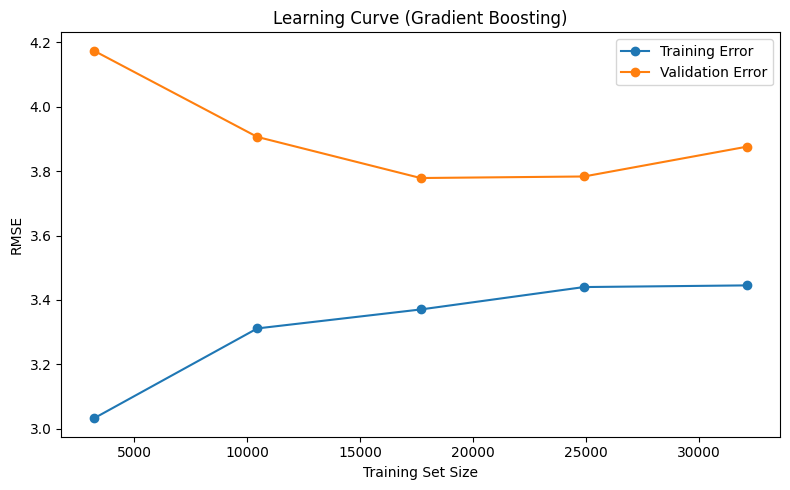

In [ ]:
# Learning curve showing training vs validation error for the gradient boosting model
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    gbr,
    X_train,
    y_train,
    cv=3,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_scores_mean = -train_scores.mean(axis=1)
val_scores_mean = -val_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_scores_mean, label='Training Error', marker='o')
plt.plot(train_sizes, val_scores_mean, label='Validation Error', marker='o')

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("Learning Curve (Gradient Boosting)")

plt.legend()
plt.tight_layout()
plt.show()

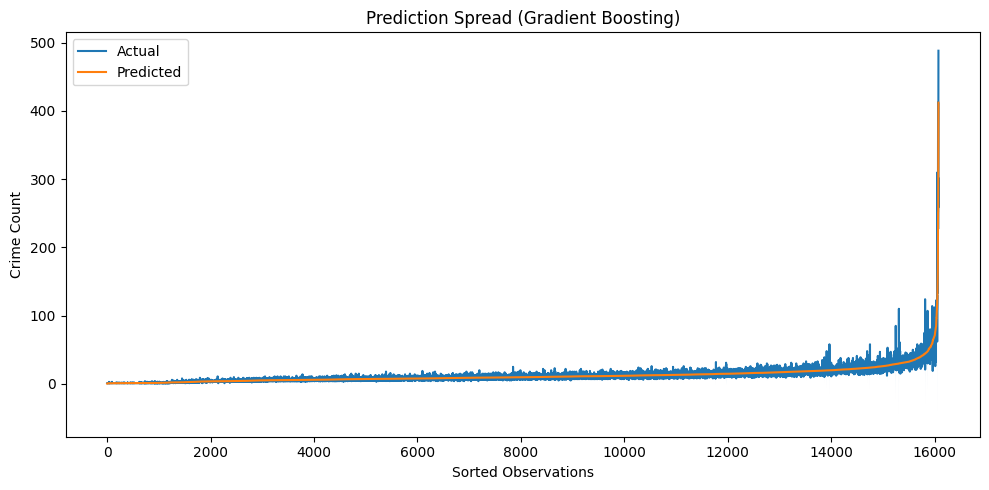

In [130]:
sorted_idx = np.argsort(y_pred_gbr)

plt.figure(figsize=(10,5))

plt.plot(y_test.values[sorted_idx], label="Actual")
plt.plot(y_pred_gbr[sorted_idx], label="Predicted")

plt.fill_between(
    range(len(y_pred_gbr)),
    y_pred_gbr[sorted_idx] - abs(y_test.values[sorted_idx] - y_pred_gbr[sorted_idx]),
    y_pred_gbr[sorted_idx] + abs(y_test.values[sorted_idx] - y_pred_gbr[sorted_idx]),
    alpha=0.2
)

plt.title("Prediction Spread (Gradient Boosting)")
plt.xlabel("Sorted Observations")
plt.ylabel("Crime Count")

plt.legend()
plt.tight_layout()
plt.show()

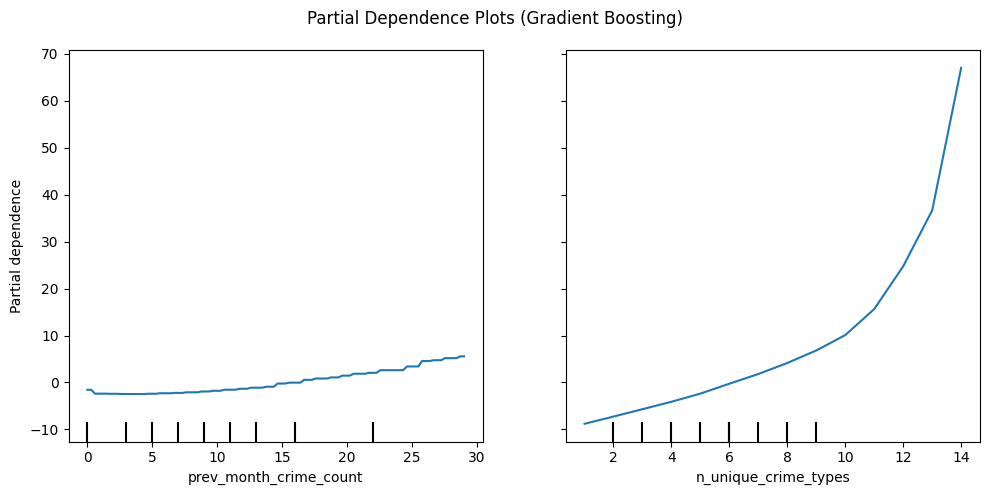

In [131]:
from sklearn.inspection import PartialDependenceDisplay

features_to_plot = ['prev_month_crime_count', 'n_unique_crime_types']

fig, ax = plt.subplots(figsize=(10,5))

PartialDependenceDisplay.from_estimator(
    gbr,
    X_train,
    features_to_plot,
    ax=ax
)

plt.suptitle("Partial Dependence Plots (Gradient Boosting)")
plt.tight_layout()
plt.show()

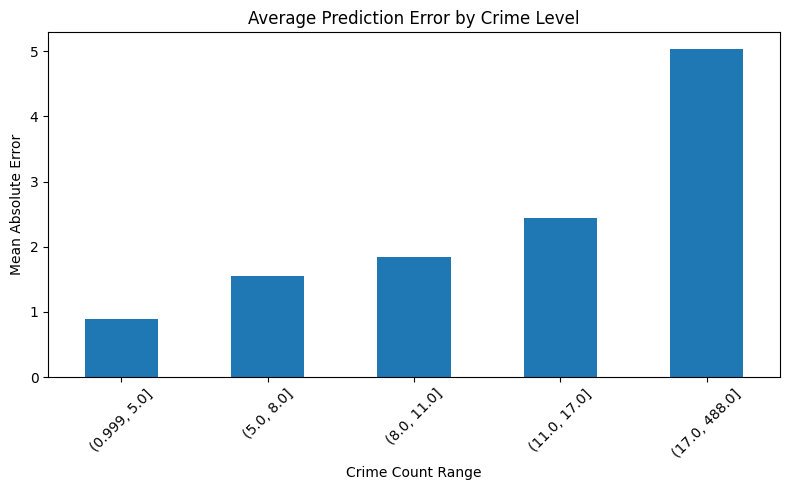

In [ ]:
# Average prediction error across different crime level ranges
import pandas as pd
import matplotlib.pyplot as plt

bins = pd.qcut(y_test, q=5)

error_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_gbr
})

error_df['Absolute Error'] = abs(error_df['Actual'] - error_df['Predicted'])
error_df['Bin'] = bins

bin_error = error_df.groupby('Bin')['Absolute Error'].mean()

plt.figure(figsize=(8,5))
bin_error.plot(kind='bar')

plt.title("Average Prediction Error by Crime Level")
plt.ylabel("Mean Absolute Error")
plt.xlabel("Crime Count Range")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

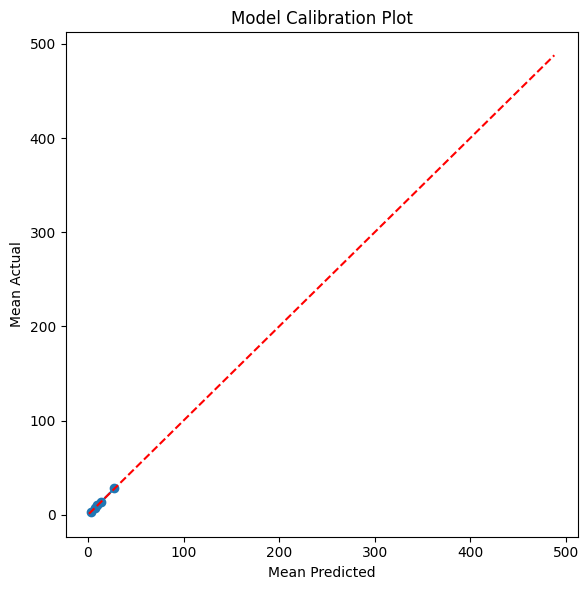

In [ ]:
# Calibration plot comparing predicted vs actual values to see how well the model lines up
calibration_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_gbr
})

calibration_df['Pred_bin'] = pd.qcut(calibration_df['Predicted'], q=5)

calibration_summary = calibration_df.groupby('Pred_bin').mean()

plt.figure(figsize=(6,6))
plt.plot(calibration_summary['Predicted'], calibration_summary['Actual'], marker='o')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Mean Predicted")
plt.ylabel("Mean Actual")
plt.title("Model Calibration Plot")

plt.tight_layout()
plt.show()

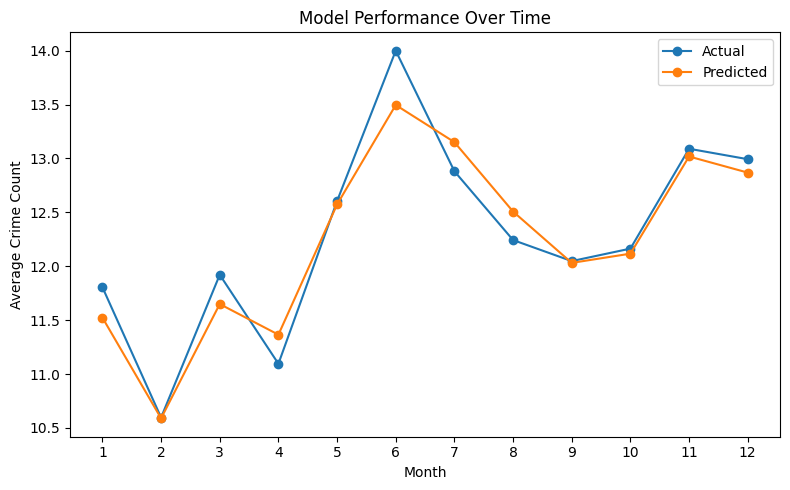

In [134]:
time_df = pd.DataFrame({
    'Month': X_test['month_num'],
    'Actual': y_test,
    'Predicted': y_pred_gbr
})

monthly_perf = time_df.groupby('Month').mean()

plt.figure(figsize=(8,5))

plt.plot(monthly_perf.index, monthly_perf['Actual'], label='Actual', marker='o')
plt.plot(monthly_perf.index, monthly_perf['Predicted'], label='Predicted', marker='o')

plt.xlabel("Month")
plt.ylabel("Average Crime Count")
plt.title("Model Performance Over Time")

plt.legend()
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

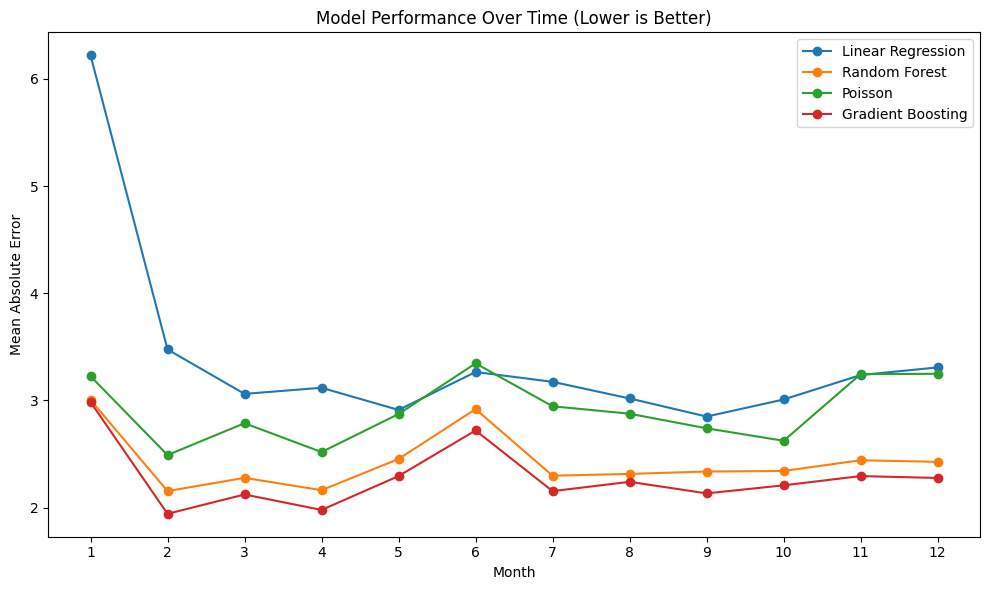

In [ ]:
# Model errors over time to compare how each model performs across months
import pandas as pd
import matplotlib.pyplot as plt

time_perf_df = pd.DataFrame({
    'Month': X_test['month_num'],
    'Actual': y_test,
    'Linear': y_pred_lr,
    'Random Forest': y_pred_rf,
    'Poisson': y_pred_poisson,
    'Gradient Boosting': y_pred_gbr
})

time_perf_df['Error_LR'] = abs(time_perf_df['Actual'] - time_perf_df['Linear'])
time_perf_df['Error_RF'] = abs(time_perf_df['Actual'] - time_perf_df['Random Forest'])
time_perf_df['Error_Poisson'] = abs(time_perf_df['Actual'] - time_perf_df['Poisson'])
time_perf_df['Error_GBR'] = abs(time_perf_df['Actual'] - time_perf_df['Gradient Boosting'])

monthly_errors = time_perf_df.groupby('Month')[[
    'Error_LR', 'Error_RF', 'Error_Poisson', 'Error_GBR'
]].mean()

plt.figure(figsize=(10,6))

plt.plot(monthly_errors.index, monthly_errors['Error_LR'], marker='o', label='Linear Regression')
plt.plot(monthly_errors.index, monthly_errors['Error_RF'], marker='o', label='Random Forest')
plt.plot(monthly_errors.index, monthly_errors['Error_Poisson'], marker='o', label='Poisson')
plt.plot(monthly_errors.index, monthly_errors['Error_GBR'], marker='o', label='Gradient Boosting')

plt.xlabel("Month")
plt.ylabel("Mean Absolute Error")
plt.title("Model Performance Over Time (Lower is Better)")

plt.legend()
plt.xticks(range(1,13))

plt.tight_layout()
plt.show()

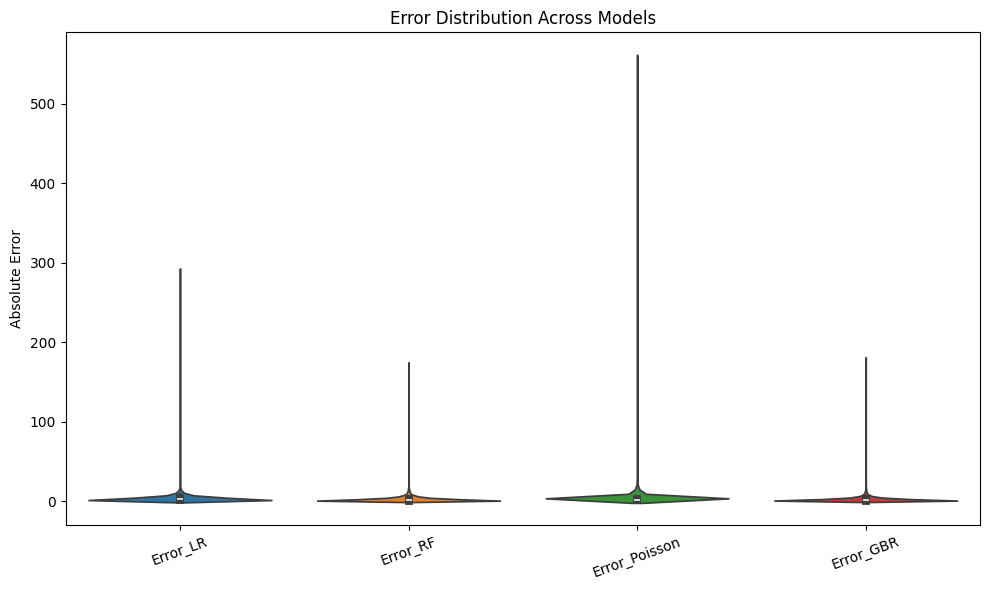

In [136]:
error_compare = time_perf_df[[
    'Error_LR',
    'Error_RF',
    'Error_Poisson',
    'Error_GBR'
]]
import seaborn as sns

plt.figure(figsize=(10,6))

sns.violinplot(data=error_compare)

plt.ylabel("Absolute Error")
plt.title("Error Distribution Across Models")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

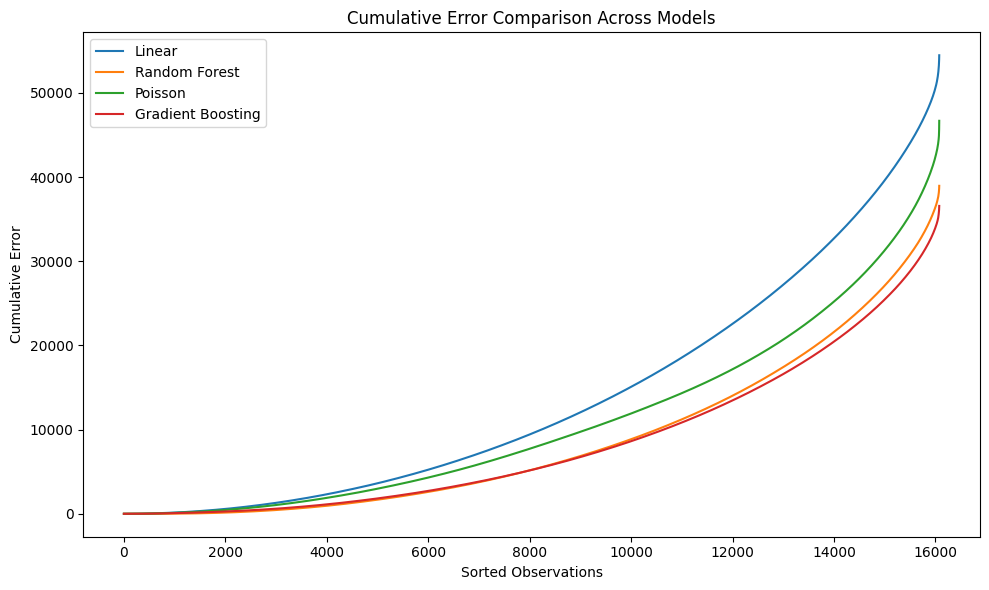

In [ ]:
# Cumulative error comparison to see which model makes fewer total mistakes overall
import numpy as np
import matplotlib.pyplot as plt

errors = {
    'Linear': np.sort(abs(y_test - y_pred_lr)),
    'Random Forest': np.sort(abs(y_test - y_pred_rf)),
    'Poisson': np.sort(abs(y_test - y_pred_poisson)),
    'Gradient Boosting': np.sort(abs(y_test - y_pred_gbr))
}

plt.figure(figsize=(10,6))

for model, err in errors.items():
    cum_err = np.cumsum(err)
    plt.plot(cum_err, label=model)

plt.xlabel("Sorted Observations")
plt.ylabel("Cumulative Error")
plt.title("Cumulative Error Comparison Across Models")

plt.legend()
plt.tight_layout()
plt.show()

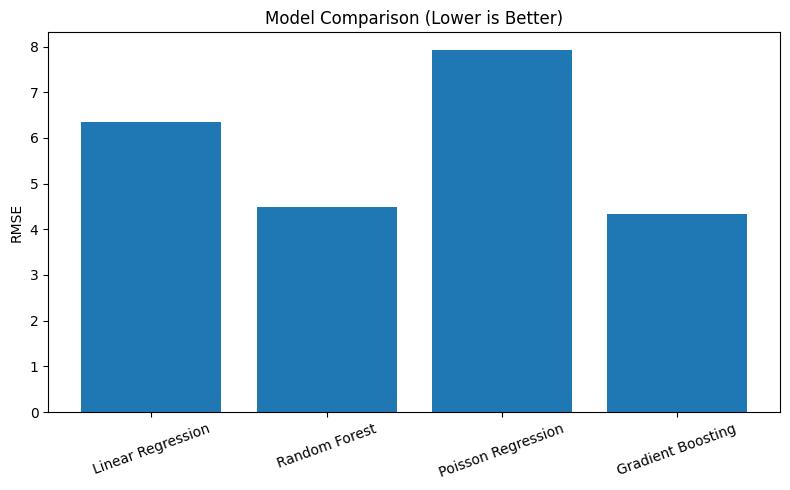

In [138]:
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['RMSE'])

plt.ylabel("RMSE")
plt.title("Model Comparison (Lower is Better)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

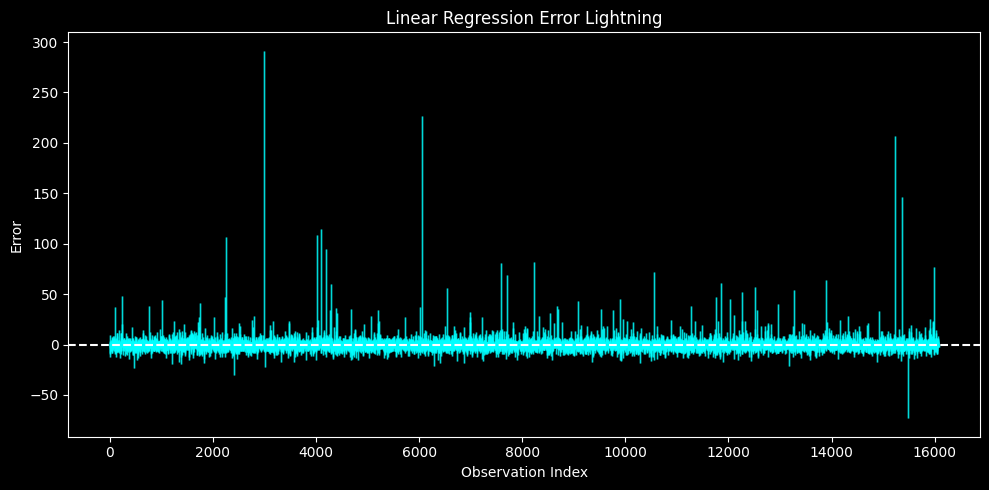

In [139]:
plt.style.use('dark_background')

errors_lr = y_test - y_pred_lr

plt.figure(figsize=(10,5))

for i in range(3):
    plt.vlines(range(len(errors_lr)), 0, errors_lr, 
               color='cyan', alpha=0.1, linewidth=2)

plt.vlines(range(len(errors_lr)), 0, errors_lr, 
           color='cyan', alpha=0.8, linewidth=0.8)

plt.axhline(0, color='white', linestyle='--')

plt.xlabel("Observation Index")
plt.ylabel("Error")
plt.title("Linear Regression Error Lightning")

plt.tight_layout()
plt.show()

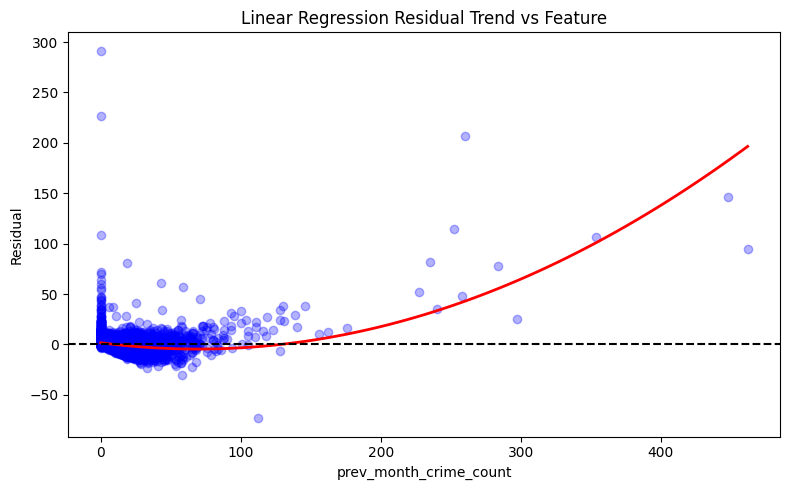

In [ ]:
# Residual plot to check how errors from linear regression behave against a key feature
plt.style.use('default')

feature = 'prev_month_crime_count'

residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(8,5))

plt.scatter(X_test[feature], residuals_lr, alpha=0.3, color='blue')

import numpy as np
z = np.polyfit(X_test[feature], residuals_lr, 2)
p = np.poly1d(z)
x_vals = np.linspace(X_test[feature].min(), X_test[feature].max(), 100)

plt.plot(x_vals, p(x_vals), color='red', linewidth=2)

plt.axhline(0, color='black', linestyle='--')

plt.xlabel(feature)
plt.ylabel("Residual")
plt.title("Linear Regression Residual Trend vs Feature")

plt.tight_layout()
plt.show()

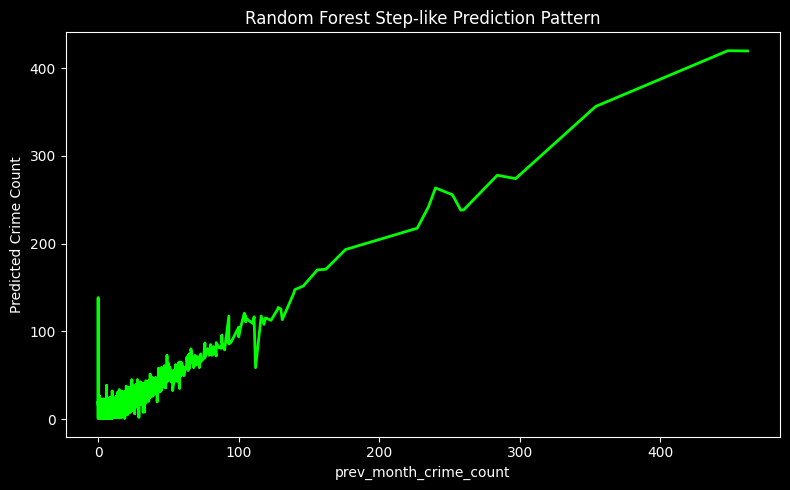

In [ ]:
plt.style.use('dark_background')

feature = 'prev_month_crime_count'

sorted_idx = np.argsort(X_test[feature])

x_sorted = X_test[feature].values[sorted_idx]
y_pred_sorted = y_pred_rf[sorted_idx]

plt.figure(figsize=(8,5))

plt.plot(x_sorted, y_pred_sorted, color='lime', linewidth=2)

plt.xlabel(feature)
plt.ylabel("Predicted Crime Count")
plt.title("Random Forest Step-like Prediction Pattern")

plt.tight_layout()
plt.show()

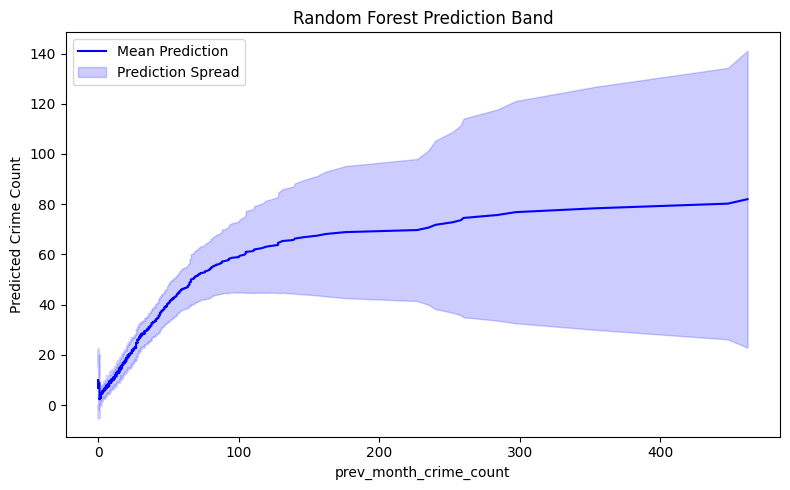

In [ ]:
# Prediction band showing average predictions and spread for random forest across a feature
plt.style.use('default')

feature = 'prev_month_crime_count'

df_rf = pd.DataFrame({
    'feature': X_test[feature],
    'pred': y_pred_rf
})

df_rf = df_rf.sort_values('feature')

window = 200

rolling_mean = df_rf['pred'].rolling(window).mean()
rolling_std = df_rf['pred'].rolling(window).std()

plt.figure(figsize=(8,5))

plt.plot(df_rf['feature'], rolling_mean, color='blue', label='Mean Prediction')

plt.fill_between(
    df_rf['feature'],
    rolling_mean - rolling_std,
    rolling_mean + rolling_std,
    color='blue',
    alpha=0.2,
    label='Prediction Spread'
)

plt.xlabel(feature)
plt.ylabel("Predicted Crime Count")
plt.title("Random Forest Prediction Band")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Hyperparameter tuning for random forest to find better settings and improve performance
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=666),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

print("Best params:", rf_grid.best_params_)
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf_tuned)))

Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
RMSE: 4.37126863445931


In [144]:
new_row = pd.DataFrame([{
    'Model': 'Tuned Random Forest',
    'R2': metrics.r2_score(y_test, y_pred_rf_tuned),
    'RMSE': np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf_tuned)),
    'MAE': metrics.mean_absolute_error(y_test, y_pred_rf_tuned)
}])

results = pd.concat([results, new_row], ignore_index=True)

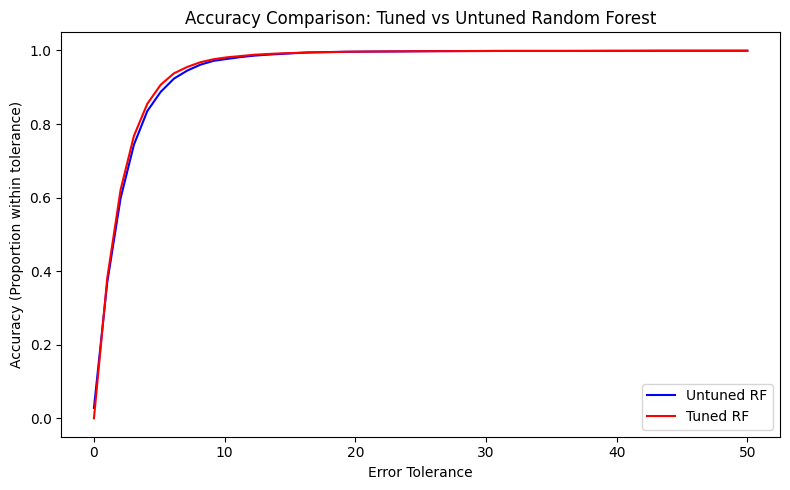

In [ ]:
# Accuracy comparison showing how tuned vs untuned random forest perform across error tolerances
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

error_untuned = abs(y_test - y_pred_rf)
error_tuned = abs(y_test - y_pred_rf_tuned)

tolerances = np.linspace(0, 50, 50)

accuracy_untuned = [(error_untuned <= t).mean() for t in tolerances]
accuracy_tuned = [(error_tuned <= t).mean() for t in tolerances]

plt.figure(figsize=(8,5))

plt.plot(tolerances, accuracy_untuned, label='Untuned RF', color='blue')
plt.plot(tolerances, accuracy_tuned, label='Tuned RF', color='red')

plt.xlabel("Error Tolerance")
plt.ylabel("Accuracy (Proportion within tolerance)")
plt.title("Accuracy Comparison: Tuned vs Untuned Random Forest")

plt.legend()
plt.tight_layout()
plt.show()

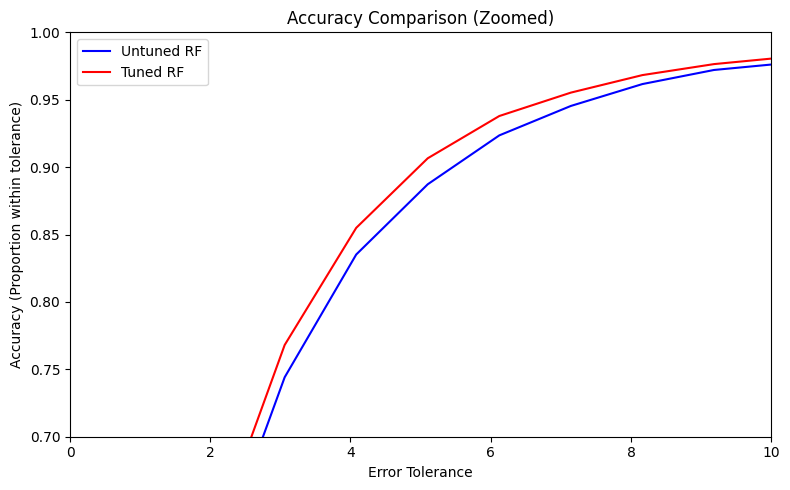

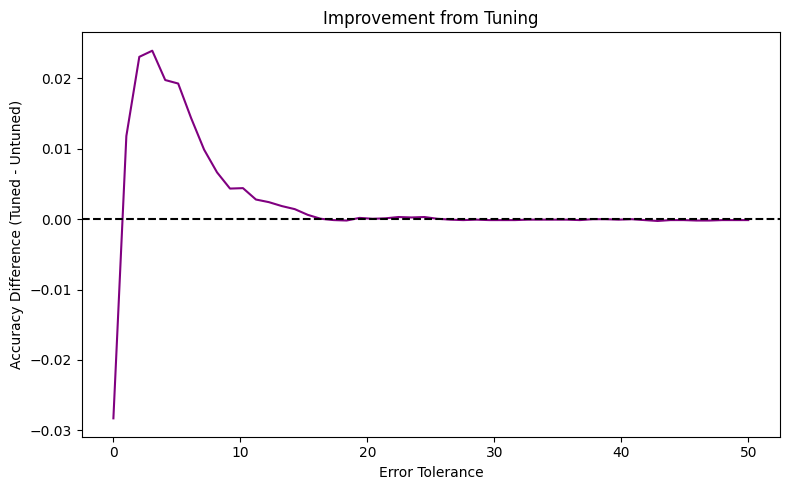

Untuned Random Forest:
RMSE: 4.490378891766305
R2: 0.9008354944735321

Tuned Random Forest:
RMSE: 4.37126863445931
R2: 0.9060265289106123


In [ ]:
# Detailed comparison showing how tuning changes random forest performance visually and numerically
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics

plt.style.use('default')

error_untuned = abs(y_test - y_pred_rf)
error_tuned = abs(y_test - y_pred_rf_tuned)

tolerances = np.linspace(0, 50, 50)

accuracy_untuned = [(error_untuned <= t).mean() for t in tolerances]
accuracy_tuned = [(error_tuned <= t).mean() for t in tolerances]

plt.figure(figsize=(8,5))

plt.plot(tolerances, accuracy_untuned, label='Untuned RF', color='blue')
plt.plot(tolerances, accuracy_tuned, label='Tuned RF', color='red')

plt.xlim(0, 10)
plt.ylim(0.7, 1.0)

plt.xlabel("Error Tolerance")
plt.ylabel("Accuracy (Proportion within tolerance)")
plt.title("Accuracy Comparison (Zoomed)")

plt.legend()
plt.tight_layout()
plt.show()

diff = np.array(accuracy_tuned) - np.array(accuracy_untuned)

plt.figure(figsize=(8,5))

plt.plot(tolerances, diff, color='purple')

plt.axhline(0, linestyle='--', color='black')

plt.xlabel("Error Tolerance")
plt.ylabel("Accuracy Difference (Tuned - Untuned)")
plt.title("Improvement from Tuning")

plt.tight_layout()
plt.show()

print("Untuned Random Forest:")
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf)))
print("R2:", metrics.r2_score(y_test, y_pred_rf))

print("\nTuned Random Forest:")
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf_tuned)))
print("R2:", metrics.r2_score(y_test, y_pred_rf_tuned))

In [ ]:

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CrimeAnalysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "2g") \
    .config("spark.network.timeout", "600s") \
    .config("spark.executor.heartbeatInterval", "60s") \
    .getOrCreate()

sc = spark.sparkContext
print("Spark running:", sc)

In [ ]:
file_path = "2023-metropolitan-street-all.csv"

spark_df = spark.read.csv(file_path, header=True, inferSchema=True)


spark_df = spark_df.sample(fraction=0.1, seed=42)

spark_df = spark_df.cache()

spark_df.show(5)

In [ ]:

if "Context" in spark_df.columns:
    spark_df = spark_df.drop("Context")


spark_df = spark_df.dropna(subset=["LSOA code", "LSOA name", "Month", "Crime type"])

In [ ]:
from pyspark.sql.functions import col, substring

spark_df = spark_df.withColumn("month_num", substring(col("Month"), 6, 2).cast("int"))

spark_df.select("Month", "month_num").show(5)

In [ ]:
from pyspark.sql.functions import count

agg_df = spark_df.groupBy("LSOA code", "LSOA name", "month_num") \
                 .agg(count("*").alias("crime_count"))

agg_df.show(10)

In [ ]:
from pyspark.sql.functions import avg

avg_crime_df = agg_df.groupBy("LSOA code") \
                    .agg(avg("crime_count").alias("avg_crime"))

avg_crime_df.show(10)

In [ ]:
pandas_df = agg_df.limit(1000).toPandas()
pandas_df.head()

In [ ]:
spark.stop()